# Limpieza y validación inicial de datos

El objetivo de este notebook es realizar la carga de datos, la validación inicial y la preparación de la estructura base para el análisis descriptivo de osteoporosis.

In [4]:
# Sistema
from pathlib import Path
import warnings

# Manipulación de datos
import numpy as np
import pandas as pd

# Estadística
from scipy import stats
import statsmodels.api as sm

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [6]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_PATH = PROJECT_DIR / "data" / "raw" / "BD_Analysis_Osteoporosis.xlsx"

if RAW_DATA_PATH.exists():
    print(f"Archivo encontrado correctamente: {RAW_DATA_PATH}")
else:
    print(f"Error: ruta no encontrada -> {RAW_DATA_PATH}")

Archivo encontrado correctamente: c:\Users\marco\Documents\analysis_osteoporosis\data\raw\BD_Analysis_Osteoporosis.xlsx


In [7]:
try:
    df_raw = pd.read_excel(RAW_DATA_PATH, engine="openpyxl")
    n_rows, n_columns = df_raw.shape
    print(f"Dataset cargado correctamente: {n_rows:,} filas y {n_columns:,} columnas")
    print("\nInformación general del dataset:")
    df_raw.info()
except Exception as error:
    print(f"Error al cargar el archivo Excel: {error}")

Dataset cargado correctamente: 405 filas y 74 columnas

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 74 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   1. Sexo                         405 non-null    int64  
 1   2. ECivil                       405 non-null    int64  
 2   3. Edad                         405 non-null    int64  
 3   4. Edad_cat                     405 non-null    int64  
 4   5. Lnac (Entidad)               405 non-null    str    
 5   6. Lnac (Municipio)             405 non-null    str    
 6   7. Lresid (Entidad):            405 non-null    str    
 7   8. Lresid (Municipio):          405 non-null    int64  
 8   9. Escolaridad                  405 non-null    int64  
 9   10. Trabaja                     405 non-null    int64  
 10  11. Tipo_empleo                 405 non-null    int64  
 11  12. Act_empleo     

In [8]:
df_raw.head()

,1. Sexo,2. ECivil,3. Edad,4. Edad_cat,5. Lnac (Entidad),6. Lnac (Municipio),7. Lresid (Entidad):,8. Lresid (Municipio):,9. Escolaridad,10. Trabaja,11. Tipo_empleo,12. Act_empleo,13. Ing_mensual,14. Ing_mensual_cat,15. Derechohabiente,16. Derechohabiente_Cat,17. Salud_Cobertura,18. Salud_Cobertura_cat,19. Enfermedad,20. Enfermedad(cod),21. Enf_cat,22. Tiempo Dx,23. Vive_Con,24. Vive_Con_cat,25. Ayuda_Enf,26. Ayuda_Enf_cat,27. Disp_Aprendizaje,28. Disp_Capacitación,29. Motivo_No_Conocer,30. Grupo_Externo_Enf,31. Tipo_Grupo_Apoyo,32. Realiza_AF,33. Tipo_AF,34. Frecuencia_AF,35. Tiempo_AF,36. Espacio_AF,37. Plan_Alimenticio,38. Autor_Dieta,39. Factores_favorables_dieta,40. Barreras_dieta,Frecuencia_frutas,Frecuencia_verduras,Frecuencia_leguminosas,Frecuencia_cereales_sg,Frecuencia_cereales_cg,Frecuencia_carnes_blancas,Frecuencia_carnes_rojas,Frecuencia_embutidos,Frecuencia_lacteos,Frecuencia_azucares_sg,Frecuencia_azucares_cg,Frecuencia_grasas,Frecuencia_alcohol,Frec_productos_light,Frutas_mas_consumidas,Verduras_mas_consumidas,Leguminosas_mas_consumidas,cereales_sg_frecuentes,cereales_cg_frecuentes,Carnes_blancas_frecuentes,Carnes_rojas_frecuentes,Embutidos_frecuentes,Lacteos_frecuentes,Azucares_sg_frecuentes,Azucares_cg_frecuentes,Grasas_frecuentes,Bebidas_alcoholicas_frecuentes,Productos_light_frecuentes,Dx_Óseo,Dx_Óseo_cat,Peso (kg),Altura (cm),IMC,IMC_Cat
0,1,1,53,1,Jalisco,Cuquio,Jalisco,0,1,0,0,0,"5,000 a 7,499",1,SSA/INSABI,1,SSA/INSABI,2,"Diabetes, Hipertensión arterial, Obesidad, Col...",1,1,4,"Pareja, Hijos",1,Algún familiar,1,1,0,4,0,0,0,0,0,0,0,0,0,No,Ninguno,2,2,4,4,2,2,2,0,2,2,0,3,0,0,"Manzana, Platano","Lechuga, Calabaza, Chayote, Zanahoria",Frijoles,Tortilla de maíz,Ninguno,Pollo,Carne de cerdo,Ninguno,Queso,Ninguna,Ninguno,Aceites,Ninguna,Ninguno,Normal,0,92,160,35.937500,3
1,0,1,65,2,Jalisco,Guadalajara,Jalisco,1,1,1,2,3,"5,000 a 7,499",1,SSA/INSABI,1,SSA/INSABI,2,"Diabetes, Hipertensión arterial, Colesterol el...",1,1,4,Pareja,1,Nadie,0,2,2,3,0,0,0,0,0,0,1,0,0,No,Ninguno,4,2,4,4,1,1,1,0,2,3,0,4,0,0,"Manzana, Mango","Calabaza, Papa, Chayote, Zanahoria","Frijoles, Lentejas","Tortilla de maíz, Arroz","Pasteles, Galletas",Pollo,"Carne de cerdo, Carne de res",Ninguno,"Leche, Queso",Azucar de mesa,Ninguno,"Aderezos, Manteca",Ninguna,Ninguno,Osteopenia,1,69,164,25.654372,2
2,1,1,54,1,Veracruz de Ignacio de la Llave,Veracruz,Veracruz de Ignacio de la Llave,0,1,0,0,0,"0 a 4,999",1,SSA/INSABI,1,SSA/INSABI,2,Sano,8,0,5,Nadie,0,Nadie,0,2,2,3,0,0,0,0,0,0,0,0,0,No,Ninguno,2,3,4,4,0,2,1,0,1,1,0,4,0,0,"Manzana, Platano, Papaya","Calabaza, Chayote, Zanahoria","Frijoles, Lentejas","Tortilla de maíz, Arroz",Ninguno,"Pollo, Pescado","Carne de cerdo, Carne de res",Ninguno,"Leche, Queso",Azucar de mesa,Ninguno,"Aceites, Mantequilla, Manteca",Ninguna,Ninguno,Osteoporósis,1,57,154,24.034407,1
3,1,0,50,1,Jalisco,Tonalá,Jalisco,0,1,1,2,1,"0 a 4,999",1,SSA/INSABI,1,SSA/INSABI,2,"Diabetes, Hipertensión arterial, Obesidad, Col...",1,1,4,Padre o madre,1,Nadie,0,2,2,3,0,0,0,0,0,0,0,0,0,No,Ninguno,0,1,4,1,0,1,3,0,0,0,0,4,0,0,Ninguna,Zanahoria,Frijoles,Tortilla de maíz,Ninguno,Pollo,Carne de res,Ninguno,Ninguno,Ninguna,Ninguno,Manteca,Ninguna,Ninguno,Normal,0,82,154,34.575814,3
4,1,1,70,3,Jalisco,Guadalajara,Jalisco,0,1,0,0,0,"0 a 4,999",1,IMSS,1,IMSS,1,Hipertensión arterial,2,1,4,"Pareja, Hijos",1,Nadie,0,2,2,3,0,0,1,1,2,2,1,0,0,No,Ninguno,2,2,1,1,1,2,2,0,4,0,0,1,0,0,"Manzana, Platano","Calabaza, Chayote, Brocoli, espinaca.",Lentejas,Tortilla de maíz,Ninguno,Pollo,Carne de res,Ninguno,"Leche, Queso",Sustituto de azúcar,Ninguno,Aceite olivo,Ninguna,Ninguno,Osteopenia,1,79,156,32.462196,3


## 2. Estandarización de Variables y Tipos de Datos

Las columnas se renombrarán a formato `snake_case` siguiendo las definiciones del `data_dictionary.md`; además, se ajustarán los tipos de datos entre variables numéricas y categóricas, y se creará la variable dependiente `alteracion_osea` para el análisis descriptivo de osteoporosis.

In [9]:
column_rename_dict = {
    "1. Sexo": "sexo",
    "2. ECivil": "estado_civil",
    "3. Edad": "edad",
    "4. Edad_cat": "edad_cat",
    "5. Lnac (Entidad)": "lugar_nacimiento_entidad",
    "5. L nac (Entidad)": "lugar_nacimiento_entidad",
    "6. Lnac (Municipio)": "lugar_nacimiento_municipio",
    "6. L nac (Municipio)": "lugar_nacimiento_municipio",
    "7. Lresid (Entidad):": "lugar_residencia_entidad",
    "7. L resid (Entidad)": "lugar_residencia_entidad",
    "8. Lresid (Municipio):": "lugar_residencia_municipio",
    "8. L resid (Municipio)": "lugar_residencia_municipio",
    "9. Escolaridad": "escolaridad",
    "10. Trabaja": "trabaja",
    "11. Tipo_empleo": "tipo_empleo",
    "12. Act_empleo": "act_empleo",
    "13. Ing_mensual": "ing_mensual",
    "14. Ing_mensual_cat": "ing_mensual_cat",
    "15. Derechohabiente": "derechohabiente",
    "16. Derechohabiente_Cat": "derechohabiente_cat",
    "16. Derechohabiente_cat": "derechohabiente_cat",
    "17. Salud_Cobertura": "salud_cobertura",
    "18. Salud_Cobertura_cat": "salud_cobertura_cat",
    "19. Enfermedad": "enfermedad",
    "20. Enfermedad(cod)": "enfermedad_cod",
    "21. Enf_cat": "enfermedad_cat",
    "21. Enfermedad_cat": "enfermedad_cat",
    "22. Tiempo Dx": "tiempo_dx",
    "23. Vive_Con": "vive_con",
    "24. Vive_Con_cat": "vive_con_cat",
    "25. Ayuda_Enf": "ayuda_enf",
    "26. Ayuda_Enf_cat": "ayuda_enf_cat",
    "26. Ayuda_Enf(cod)": "ayuda_enf_cat",
    "27. Disp_Aprendizaje": "disp_aprendizaje",
    "28. Disp_Capacitación": "disp_capacitacion",
    "29. Motivo_No_Conocer": "motivo_no_conocer",
    "30. Grupo_Externo_Enf": "grupo_externo_enf",
    "31. Tipo_Grupo_Apoyo": "tipo_grupo_apoyo",
    "32. Realiza_AF": "realiza_af",
    "33. Tipo_AF": "tipo_af",
    "34. Frecuencia_AF": "frecuencia_af",
    "35. Tiempo_AF": "tiempo_af",
    "36. Espacio_AF": "espacio_af",
    "37. Plan_Alimenticio": "plan_alimenticio",
    "38. Autor_Dieta": "autor_dieta",
    "39. Factores_favorables_dieta": "factores_favorables_dieta",
    "40. Barreras_dieta": "barreras_dieta",
    "41. Dx_Óseo": "dx_oseo",
    "Dx_Óseo": "dx_oseo",
    "42. Dx_Óseo_cat": "dx_oseo_cat",
    "Dx_Óseo_cat": "dx_oseo_cat",
    "43. Peso (kg)": "peso_(kg)",
    "Peso (kg)": "peso_(kg)",
    "44. Altura (cm)": "altura_(cm)",
    "Altura (cm)": "altura_(cm)",
    "45. IMC": "imc",
    "IMC": "imc",
    "46. IMC_Cat": "imc_cat",
    "IMC_Cat": "imc_cat",
}

df_clean = df_raw.rename(columns=column_rename_dict).copy()
df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_')

print(f"Columnas originales: {df_raw.shape[1]}")
print(f"Columnas estandarizadas: {df_clean.shape[1]}")
df_clean.columns[:15].tolist()


Columnas originales: 74
Columnas estandarizadas: 74


['sexo',
 'estado_civil',
 'edad',
 'edad_cat',
 'lugar_nacimiento_entidad',
 'lugar_nacimiento_municipio',
 'lugar_residencia_entidad',
 'lugar_residencia_municipio',
 'escolaridad',
 'trabaja',
 'tipo_empleo',
 'act_empleo',
 'ing_mensual',
 'ing_mensual_cat',
 'derechohabiente']

In [10]:
continuous_columns = ["edad", "peso_(kg)", "altura_(cm)", "imc"]

for column in continuous_columns:
    if column not in df_clean.columns:
        raise KeyError(f"No se encontró la columna continua esperada: {column}")
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

if "dx_oseo_cat" in df_clean.columns:
    dx_oseo_numeric = pd.to_numeric(df_clean["dx_oseo_cat"], errors="coerce")
    df_clean["alteracion_osea"] = np.where(
        dx_oseo_numeric.eq(0),
        0,
        np.where(dx_oseo_numeric.eq(1), 1, np.nan),
    )
elif "dx_oseo" in df_clean.columns:
    dx_oseo_normalized = (
        df_clean["dx_oseo"]
        .astype("string")
        .str.normalize("NFKD")
        .str.encode("ascii", errors="ignore")
        .str.decode("utf-8")
        .str.lower()
        .str.strip()
    )
    df_clean["alteracion_osea"] = np.where(
        dx_oseo_normalized.eq("normal"),
        0,
        np.where(dx_oseo_normalized.isin(["osteopenia", "osteoporosis"]), 1, np.nan),
    )
else:
    raise KeyError("No se encontró una columna de diagnóstico óseo para construir alteracion_osea.")

df_clean["alteracion_osea"] = pd.to_numeric(
    df_clean["alteracion_osea"], errors="coerce"
).astype("Int64")

categorical_columns = ["sexo", "alteracion_osea", "trabaja", "realiza_af"]

for column in categorical_columns:
    if column not in df_clean.columns:
        raise KeyError(f"No se encontró la columna categórica esperada: {column}")
    df_clean[column] = df_clean[column].astype("category")

df_clean[continuous_columns + categorical_columns].head()


,edad,peso_(kg),altura_(cm),imc,sexo,alteracion_osea,trabaja,realiza_af
0,53,92,160,35.937500,1,0,0,0
1,65,69,164,25.654372,0,1,1,0
2,54,57,154,24.034407,1,1,0,0
3,50,82,154,34.575814,1,0,1,0
4,70,79,156,32.462196,1,1,0,1


In [11]:
print("Distribución de alteracion_osea:")
print(df_clean["alteracion_osea"].value_counts(dropna=False))

df_clean[["edad", "imc", "sexo", "alteracion_osea"]].info()


Distribución de alteracion_osea:
alteracion_osea
1    344
0     61
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   edad             405 non-null    int64   
 1   imc              405 non-null    float64 
 2   sexo             405 non-null    category
 3   alteracion_osea  405 non-null    category
dtypes: category(2), float64(1), int64(1)
memory usage: 7.3 KB


## 3. Auditoría de Calidad: Duplicados y Valores Nulos

Se verificará la integridad de los registros antes del análisis descriptivo, identificando filas duplicadas y valores nulos en variables indispensables para el análisis multivariado posterior.

In [12]:
duplicated_rows = df_clean.duplicated().sum()
print(f"Filas exactamente duplicadas encontradas: {duplicated_rows}")

if duplicated_rows > 0:
    df_clean.drop_duplicates(inplace=True)
    df_clean.reset_index(drop=True, inplace=True)
    print(f"Duplicados eliminados. Dimensiones actuales: {df_clean.shape}")
else:
    print("No se encontraron duplicados exactos.")


Filas exactamente duplicadas encontradas: 0
No se encontraron duplicados exactos.


In [13]:
null_percent = df_clean.isna().mean().mul(100).sort_values(ascending=False)
columns_with_nulls = null_percent[null_percent > 0]

print("Columnas con valores nulos (%):")
display(columns_with_nulls.to_frame(name="porcentaje_nulos"))

required_model_columns = ["alteracion_osea", "edad", "imc"]
initial_shape = df_clean.shape

df_clean = df_clean.dropna(subset=required_model_columns).copy()
df_clean.reset_index(drop=True, inplace=True)

print(f"Dimensiones antes del filtro crítico: {initial_shape}")
print(f"Dimensiones después del filtro crítico: {df_clean.shape}")


Columnas con valores nulos (%):


,porcentaje_nulos


Dimensiones antes del filtro crítico: (405, 75)
Dimensiones después del filtro crítico: (405, 75)


## 4. Exportación de Datos Procesados

El dataset limpio se guardará en un formato binario para mantener intactos los tipos de datos categóricos de pandas y facilitar la etapa posterior de análisis exploratorio.

In [18]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_PATH = PROJECT_DIR / "data" / "processed" / "BD_Clean_Osteoporosis.parquet"
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
PICKLE_FALLBACK_PATH = PROCESSED_DATA_PATH.with_suffix(".pkl")

# Para exportar a Parquet se requiere pyarrow o fastparquet.
# Si el motor de Parquet falla, .to_pickle() preserva de forma segura los dtypes de pandas.
try:
    df_clean.to_parquet(PROCESSED_DATA_PATH, index=False)
    exported_path = PROCESSED_DATA_PATH
    export_format = "Parquet"
except Exception as error:
    df_clean.to_pickle(PICKLE_FALLBACK_PATH)
    exported_path = PICKLE_FALLBACK_PATH
    export_format = "Pickle"
    print("No se pudo exportar a Parquet; se usó Pickle como alternativa segura.")
    print(f"Detalle del error: {type(error).__name__}: {error}")

print(f"Dataset procesado guardado correctamente en: {exported_path}")
print(f"Formato de exportación: {export_format}")
print(f"Dimensiones finales para análisis exploratorio: {df_clean.shape}")

Dataset procesado guardado correctamente en: c:\Users\marco\Documents\analysis_osteoporosis\data\processed\BD_Clean_Osteoporosis.parquet
Formato de exportación: Parquet
Dimensiones finales para análisis exploratorio: (405, 75)


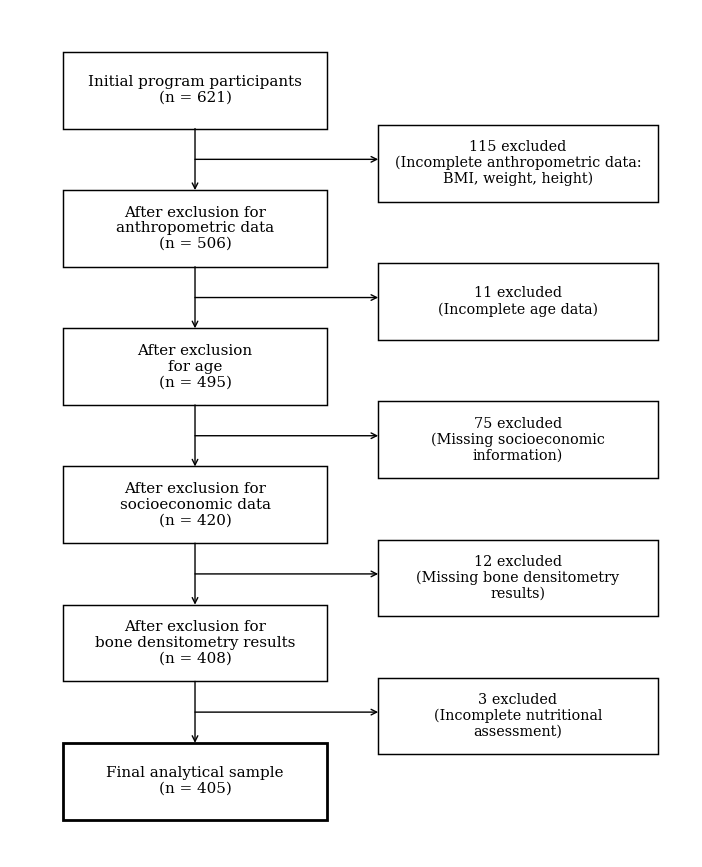

In [3]:
# Participant flow diagram — CONSORT style
# CONSORT flowchart — added

import os
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs"
MPLCONFIG_DIR = OUTPUT_DIR / ".matplotlib"
OUTPUT_DIR.mkdir(exist_ok=True)
MPLCONFIG_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR.resolve()))

import matplotlib

IN_NOTEBOOK = "ipykernel" in sys.modules
if not IN_NOTEBOOK:
    matplotlib.use("Agg", force=True)

import matplotlib.pyplot as plt
import matplotlib.patches as patches

FONT_FAMILY = "DejaVu Serif"
MAIN_X = 3.25
EXCLUSION_X = 7.7
MAIN_WIDTH = 3.65
MAIN_HEIGHT = 0.86
EXCLUSION_WIDTH = 3.85
EXCLUSION_HEIGHT = 0.86
BOX_LINEWIDTH = 1.05
FINAL_LINEWIDTH = 2.0
ARROW_LINEWIDTH = 1.0

main_steps = [
    ("Initial program participants\n(n = 621)", 10.8),
    ("After exclusion for\nanthropometric data\n(n = 506)", 9.25),
    ("After exclusion\nfor age\n(n = 495)", 7.7),
    ("After exclusion for\nsocioeconomic data\n(n = 420)", 6.15),
    ("After exclusion for\nbone densitometry results\n(n = 408)", 4.6),
    ("Final analytical sample\n(n = 405)", 3.05),
]

exclusions = [
    ("115 excluded\n(Incomplete anthropometric data:\nBMI, weight, height)", 9.98),
    ("11 excluded\n(Incomplete age data)", 8.43),
    ("75 excluded\n(Missing socioeconomic\ninformation)", 6.88),
    ("12 excluded\n(Missing bone densitometry\nresults)", 5.33),
    ("3 excluded\n(Incomplete nutritional\nassessment)", 3.78),
]

fig, ax = plt.subplots(figsize=(8.8, 11.0))
ax.set_xlim(0.7, 10.1)
ax.set_ylim(2.2, 11.7)
ax.axis("off")


def create_simple_box(
    ax,
    center,
    text,
    width,
    height,
    linewidth=BOX_LINEWIDTH,
    fontsize=10.9,
):
    x, y = center
    box = patches.Rectangle(
        (x - width / 2, y - height / 2),
        width,
        height,
        linewidth=linewidth,
        edgecolor="black",
        facecolor="white",
    )
    ax.add_patch(box)
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontfamily=FONT_FAMILY,
        linespacing=1.15,
    )
    return box


def draw_arrow(start, end):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(
            arrowstyle="->",
            lw=ARROW_LINEWIDTH,
            color="black",
            shrinkA=0,
            shrinkB=0,
            mutation_scale=10,
        ),
    )


for label, y in main_steps[:-1]:
    create_simple_box(ax, (MAIN_X, y), label, MAIN_WIDTH, MAIN_HEIGHT)

final_label, final_y = main_steps[-1]
create_simple_box(
    ax,
    (MAIN_X, final_y),
    final_label,
    MAIN_WIDTH,
    MAIN_HEIGHT,
    linewidth=FINAL_LINEWIDTH,
)

for label, y in exclusions:
    create_simple_box(
        ax,
        (EXCLUSION_X, y),
        label,
        EXCLUSION_WIDTH,
        EXCLUSION_HEIGHT,
        fontsize=10.4,
    )

for (_, y_top), (_, y_bottom) in zip(main_steps, main_steps[1:]):
    draw_arrow((MAIN_X, y_top - MAIN_HEIGHT / 2), (MAIN_X, y_bottom + MAIN_HEIGHT / 2))

for (_, y), (_, y_next) in zip(main_steps, main_steps[1:]):
    midpoint_y = (y + y_next) / 2
    draw_arrow(
        (MAIN_X, midpoint_y),
        (EXCLUSION_X - EXCLUSION_WIDTH / 2, midpoint_y),
    )

plt.savefig(OUTPUT_DIR / "flowchart_participants.pdf",
            bbox_inches="tight", dpi=300)
plt.savefig(OUTPUT_DIR / "flowchart_participants.svg",
            bbox_inches="tight", format="svg")
plt.savefig(OUTPUT_DIR / "flowchart_participants.png",
            bbox_inches="tight", dpi=600)

if IN_NOTEBOOK:
    plt.show()
else:
    plt.close(fig)